**EXERCICE 1 : API complète et maintenable** <br>

Compléter LinkedList avec : <br>

+ is_empty() <br>

+ __len__() (taille) sans recalculer à chaque fois <br>

+ to_list() (conversion Python list) <br>

+ from_iterable(iterable) (constructeur/chargement <br>

In [31]:
class LinkedList:
    def __init__(self):
        self.head = None
        self.size = 0

    def is_empty(self):
        return self.head is None

    def __len__(self):
        return self.size

    def insert_at_head(self, data):
        new_node = Node(data)
        new_node.next = self.head
        self.head = new_node
        self.size += 1

    def to_list(self):
        out = []
        current = self.head
        while current:
            out.append(current.data)
            current = current.next
        return out

    @classmethod
    def from_iterable(cls, iterable):
        list_chai = cls()
        stack = list(iterable)
        for x in reversed(stack):
            list_chai.insert_at_head(x)
        return list_chai

    def delete(self, value):
        current = self.head
        prev = None

        while current:
            if current.data == value:
                if prev:
                    prev.next = current.next
                else:
                    self.head = current.next
                self.size -= 1
                return True
            prev = current
            current = current.next
        return False

In [32]:
class Node:
    def __init__(self, data):
        self.data = data
        self.next = None


list1 = LinkedList()

list1.insert_at_head(1)
list1.insert_at_head(2)
list1.insert_at_head(3)
list1.insert_at_head(4)

print(list1.to_list())

[4, 3, 2, 1]


In [16]:
del list1

In [33]:
list2 = LinkedList.from_iterable([1, 2, 3, 4])
print(list2.to_list())

[1, 2, 3, 4]


In [34]:
list2.delete(2)

True

In [35]:
list2.to_list()

[1, 3, 4]

In [36]:
list2.__len__()

3

**EXERCICE 2 : Insertion en fin + analyse** <br>

Ajouter append(data) (insertion en fin) sans attribut tail. <br>

In [29]:
class Node:
    def __init__(self, data):
        self.data = data
        self.next = None


class LinkedList:
    def __init__(self):
        self.head = None
        self.size = 0

    def append(self, data):
        new_node = Node(data)

        if not self.head:
            self.head = new_node
            self.size += 1
            return

        current = self.head
        while current.next:
            current = current.next

        current.next = new_node
        self.size += 1

    def to_list(self):
        result = []
        current = self.head

        while current:
            result.append(current.data)
            current = current.next

        return result


In [30]:
list3 = LinkedList()

list3.append(10)
list3.append(20)
list3.append(30)

print(list3.to_list())

[10, 20, 30]


**EXERCICE 3 : Optimisation avec pointeur tail** <br>

Modifier la structure pour que append devienne O(1). <br>

In [10]:
class LinkedList:
    def __init__(self):
        self.head = None
        self.tail = None
        self.size = 0

    def insert_at_head(self, data):
        new_node = Node(data)
        new_node.next = self.head
        self.head = new_node
        if self.tail is None:
            self.tail = new_node
        self.size += 1

    def append(self, data):
        new_node = Node(data)
        if self.tail is None:
            self.head = self.tail = new_node
        else:
            self.tail.next = new_node
            self.tail = new_node
        self.size += 1

    def to_list(self):
        result = []
        current = self.head

        while current:
            result.append(current.data)
            current = current.next

        return result

    def delete(self, value):
        current = self.head
        prev = None

        while current:
            if current.data == value:
                if prev:
                    prev.next = current.next
                else:
                    self.head = current.next

                if current == self.tail:
                    self.tail = prev

                self.size -= 1
                return True
            prev = current
            current = current.next
        return False

In [14]:
class Node:
    def __init__(self, data):
        self.data = data
        self.next = None

list4 = LinkedList()

list4.append(10)
list4.append(20)
list4.append(30)
list4.to_list()

[10, 20, 30]

In [15]:
list4.insert_at_head(5)
list4.to_list()

[5, 10, 20, 30]

In [16]:
list4.delete(20)
list4.to_list()

[5, 10, 30]

**Exercice 3 : Construire un BST + vérifier le tri via Inorder** <br>

1. Implémenter les méthodes : insert, search, inorder. <br>

2. Insérer : 50, 30, 70, 20, 40, 60, 80. <br>

3. Vérifier que inorder renvoie une liste triée. <br>

In [17]:
class BSTNode:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

class BST:
    def __init__(self):
        self.root = None

    def insert(self, value):
        if self.root is None:
            self.root = BSTNode(value)
            return
        self._insert(self.root, value)

    def _insert(self, node, value):
        if value < node.value:
            if node.left is None:
                node.left = BSTNode(value)
            else:
                self._insert(node.left, value)
        else:
            if node.right is None:
                node.right = BSTNode(value)
            else:
                self._insert(node.right, value)

    def search(self, value):
        return self._search(self.root, value)

    def _search(self, node, value):
        if node is None:
            return False
        if node.value == value:
            return True
        if value < node.value:
            return self._search(node.left, value)
        return self._search(node.right, value)

    def inorder(self):
        out = []
        def dfs(node):
            if node:
                dfs(node.left)
                out.append(node.value)
                dfs(node.right)
        dfs(self.root)
        return out

In [19]:
bst = BST()
for val in [50, 30, 70, 20, 40, 60, 80]:
    bst.insert(val)
print(bst.inorder())

[20, 30, 40, 50, 60, 70, 80]


In [20]:
bst.search(10)

False

In [21]:
bst.search(80)

True

In [54]:
class BST(BST):
    def min(self):
        node = self.root
        if node is None:
         return None

        while node.left is not None:
         node = node.left

        return node.value


    def max(self):
        node = self.root
        if node is None:
            return None

        while node.right is not None:
            node = node.right

        return node.value

In [55]:
bst = BST()

for v in [50, 30, 70, 20, 40, 60, 80]:
    bst.insert(v)

print("Minimum :", bst.min())
print("Maximum :", bst.max())

Minimum : 20
Maximum : 80


In [56]:
class BST(BST):
    def dessin_arbre(self):
        if self.root is None:
            print("(arbre vide)")
            return
        self._dessin_arbre(self.root, "", True)

    def _dessin_arbre(self, node, prefix, is_left):
        if node.right is not None:
            new_prefix = prefix + ("│   " if is_left else "    ")
            self._dessin_arbre(node.right, new_prefix, False)

        print(prefix + ("└── " if is_left else "┌── ") + str(node.value))

        if node.left is not None:
            new_prefix = prefix + ("    " if is_left else "│   ")
            self._dessin_arbre(node.left, new_prefix, True)

In [57]:
bst = BST()

for v in [50, 30, 70, 20, 40, 60, 80]:
    bst.insert(v)

bst.dessin_arbre()

│       ┌── 80
│   ┌── 70
│   │   └── 60
└── 50
    │   ┌── 40
    └── 30
        └── 20


In [24]:
import matplotlib.pyplot as plt
import random
plt.rcParams['figure.figsize'] = [20, 6]

In [58]:
def dessiner(t, labels=True):
    d = 512
    pad =20
    dy =(d - 2*pad) // (hauteur(t))
    dessiner_aux(t,(pad,d - pad, pad, d - pad), dy, labels)
    plt.axis([0, d, 0, d])
    plt.axis('off')
    plt.show()

In [59]:
def dessiner_aux(t, box, dy, labels):
    if est_vide(t):
        return
    x1, x2, y1, y2 = box
    xm = (x1 + x2) // 2
    x,t1,t2 = t
    dessiner_aux(t1, (x1, xm, y1, y2 - dy), dy, labels)
    dessiner_aux(t2, (xm, x2, y1, y2 - dy), dy, labels)
    plt.plot([xm, xm], [y1, y1 - dy], color='black')
    u, v = fils_gauche(t), fils_droit(t)
    if not est_vide(t1):
        a,b=((xm,(x1+xm)/2),(y2,y2 - dy))
        plt.plot(a,b,'k',marker='o', markerfacecolor='r')
    if not est_vide(t2):
        c,d=((xm,(x2+xm)/2),(y2,y2 - dy))
        plt.plot(c,d,'k',marker='o', markerfacecolor='r')
    if labels:
        plt.text(xm - 5, y2 + 5, str(racine(t)), horizontalalignment='center',
                 verticalalignment='center', fontsize=12)

In [60]:
def hauteur(t):
    if est_vide(t):
        return 0
    else:
        u,v=fils_gauche(t),fils_droit(t)
        return 1+max(hauteur(u),hauteur(v))

In [61]:
def vide(): return None
def racine(t): return t[0]
def fils_gauche(t): return t[1]
def fils_droit(t): return t[2]
def fils(t): return (gauche(t), droit(t))
def est_vide(t): return t==None
def arbre(x,u,v): return (x,u,v)

In [62]:
exemple2 = ('A',('B',('C',('E', None,None),None),('D', None,None)),
            ('F',('G',('I', None, None),None),('H',('J', None, None), None)))

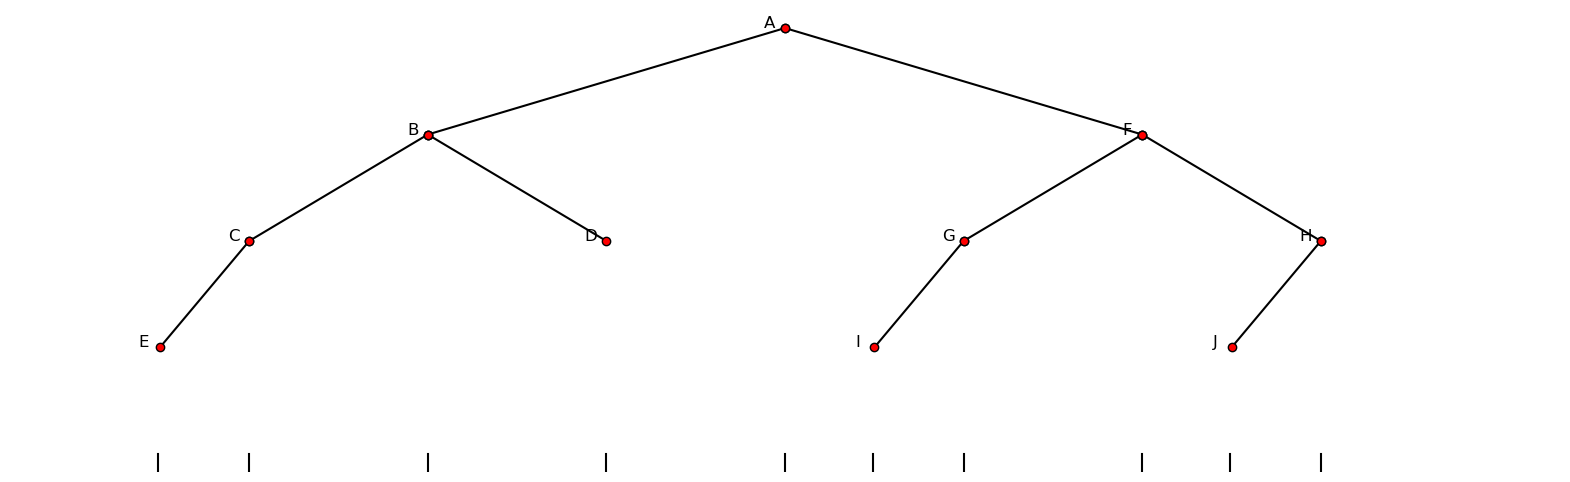

In [63]:
dessiner(exemple2)

**Hauteur**

In [64]:
def hauteur(t):
    if est_vide(t):
        return 0
    else:
        u,v=fils_gauche(t),fils_droit(t)
        return 1+max(hauteur(u),hauteur(v))

In [65]:
print(hauteur(exemple2)-1)

3


**Nombre de noeuds**

In [66]:
def nombre_noeuds(t):
    if est_vide(t):
        return 0
    else:
        _,u,v=racine(t),fils_gauche(t),fils_droit(t)
        return 1+nombre_noeuds(u)+nombre_noeuds(v)

In [67]:
print(nombre_noeuds(exemple2))

10


**Liste des feuilles**

In [68]:
def liste_feuilles(t):
    if est_vide(t):
        return []
    elif est_vide(fils_gauche(t)) and est_vide(fils_droit(t)):
        return [racine(t)]
    else:
        u,v=fils_gauche(t),fils_droit(t)
        return liste_feuilles(u)+liste_feuilles(v)

In [69]:
print(liste_feuilles(exemple2))

['E', 'D', 'I', 'J']


**Exo4**

In [72]:
class BST(BST):
    def search_with_comparisons(self, value):
        node = self.root
        compt = 0
        while node is not None:
            compt += 1
            if value == node.value:
                return node, compt
            node = node.left if value < node.value else node.right
        return None, compt

In [76]:
bst = BST()

for v in [50, 30, 70, 20, 40, 60, 80]:
    bst.insert(v)

In [77]:
node1, compt1 = bst.search_with_comparisons(60)
print(node1.value if node1 else None, compt1)

60 3


In [84]:
class BST(BST):
    def delete(self, value):
        self.root = self._delete(self.root, value)

    def _delete(self, node, value):
        if node is None:
            return None

        if value < node.value:
            node.left = self._delete(node.left, value)
            return node
        if value > node.value:
            node.right = self._delete(node.right, value)
            return node

        
        if node.left is None:
            return node.right
        if node.right is None:
            return node.left

        succ = self._min_node(node.right)
        node.value = succ.value
        node.right = self._delete(node.right, succ.value)
        return node

    def _min_node(self, node):
        while node.left:
            node = node.left
        return node

In [85]:
bst = BST()

for v in [50, 30, 70, 20, 40, 60, 80]:
    bst.insert(v)

In [86]:
bst.inorder()

[20, 30, 40, 50, 60, 70, 80]

**Suppression d'une feuilles**

In [87]:
bst.delete(20)

In [88]:
bst.inorder()

[30, 40, 50, 60, 70, 80]

**supprimer un nœud avec 1 enfant**

In [89]:
bst.delete(30)

In [90]:
bst.inorder()

[40, 50, 60, 70, 80]

**supprimer un nœud avec 2 enfants**

In [91]:
bst.delete(50)

In [92]:
bst.inorder()

[40, 60, 70, 80]